# Food Image Classification
This project uses **TensorFlow/Keras** to build a food image classification model. It applies **transfer learning** with a pretrained **ConvNeXt** model to identify the type of food shown in an input image.


## Import required libraries

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

I0000 00:00:1783020284.115897   17929 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783020284.151789   17929 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783020284.812832   17929 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
image_dir = Path("/mnt/c/food_image_classification")

## Create a dataframe of image paths and labels

In [3]:
filepaths = list(image_dir.glob("**/*.jpg"))
labels = list(map(lambda x:os.path.split(os.path.split(x)[0])[1],filepaths))
filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels= pd.Series(labels, name='Label')
images = pd.concat([filepaths, labels], axis =1)
category_samples=[]
for category in images ['Label'].unique():
    category_slice = images.query('Label == @category')
    category_samples.append(category_slice.sample(200, random_state=1))
image_df= pd.concat(category_samples, axis=0).sample(frac=1.0, random_state=1).reset_index(drop=True)

In [4]:
image_df

,Filepath,Label
0,/mnt/c/food_image_classification/images/cevich...,ceviche
1,/mnt/c/food_image_classification/images/pho/27...,pho
2,/mnt/c/food_image_classification/images/donuts...,donuts
3,/mnt/c/food_image_classification/images/gyoza/...,gyoza
4,/mnt/c/food_image_classification/images/spaghe...,spaghetti_bolognese
...,...,...
20195,/mnt/c/food_image_classification/images/hot_an...,hot_and_sour_soup
20196,/mnt/c/food_image_classification/images/sashim...,sashimi
20197,/mnt/c/food_image_classification/images/club_s...,club_sandwich
20198,/mnt/c/food_image_classification/images/lobste...,lobster_bisque


## Train-Test Split

In [5]:
train_df, test_df = train_test_split(image_df, train_size=0.7, shuffle=True, random_state=1)

## Create image preprocessing generators

In [6]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.convnext.preprocess_input,
    validation_split=0.2,horizontal_flip=True,zoom_range=0.1)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.convnext.preprocess_input)

In [7]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224,224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=False,
    seed=42,
    subset='training'
)
val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224,224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=False,
    seed=42,
    subset='validation'
)
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224,224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=False
)

Found 11312 validated image filenames belonging to 101 classes.
Found 2828 validated image filenames belonging to 101 classes.
Found 6060 validated image filenames belonging to 101 classes.


## Modeling

In [8]:
pretrained_model=tf.keras.applications.ConvNeXtTiny(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False


I0000 00:00:1783020139.231107   16014 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9554 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
inputs= pretrained_model.input
x= tf.keras.layers.Dense(128, activation ='relu')(pretrained_model.output)
x = tf.keras.layers.Dropout(0.3)(x)
x= tf.keras.layers.Dense(128, activation ='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(101,activation='softmax')(x)
model=tf.keras.Model(inputs,outputs)
print(model.summary())


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, 56, 56,    │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│                     │ 96)               │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │      4,800 │ add[0][0]         │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │         96 │ convnext_tiny_st

 Total params: 27,948,101 (106.61 MB)

 Trainable params: 127,973 (499.89 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

None


## Compile and train the model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )]
)


Epoch 1/10


I0000 00:00:1783020141.212477   16014 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783020145.214728   16256 service.cc:153] XLA service 0x752bac051ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783020145.214753   16256 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1783020145.341424   16256 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783020146.086866   16256 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1783020146.190853   16256 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14255__.353
I0000 00:00:1783020146.313620   16256 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints s

 46/177 ━━━━━━━━━━━━━━━━━━━━ 48s 371ms/step - accuracy: 0.0391 - loss: 4.5447

I0000 00:00:1783020174.439762   16256 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14255__.353
I0000 00:00:1783020174.901438   16812 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_170', 9224 bytes spill stores, 9016 bytes spill loads

I0000 00:00:1783020175.352587   16818 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_158', 9288 bytes spill stores, 9116 bytes spill loads

I0000 00:00:1783020175.528505   16256 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783020175.852838   16800 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_78', 316 bytes

177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.1293 - loss: 3.9015

I0000 00:00:1783020237.351006   16258 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783020237.788449   17360 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_154', 56 bytes spill stores, 56 bytes spill loads

I0000 00:00:1783020237.817396   16258 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


## Results and Model Evaluation


In [ ]:
result = model.evaluate(test_images, verbose =0)
print("Test accuracy: {:.2f}%".format(result[1]*100))

Test accuracy: 54.74%


In [ ]:
predictions = np.argmax(model.predict(test_images), axis=1)
cm = confusion_matrix(test_images.labels, predictions)
clr = classification_report(test_images.labels, predictions,target_names=test_images.class_indices)

95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step


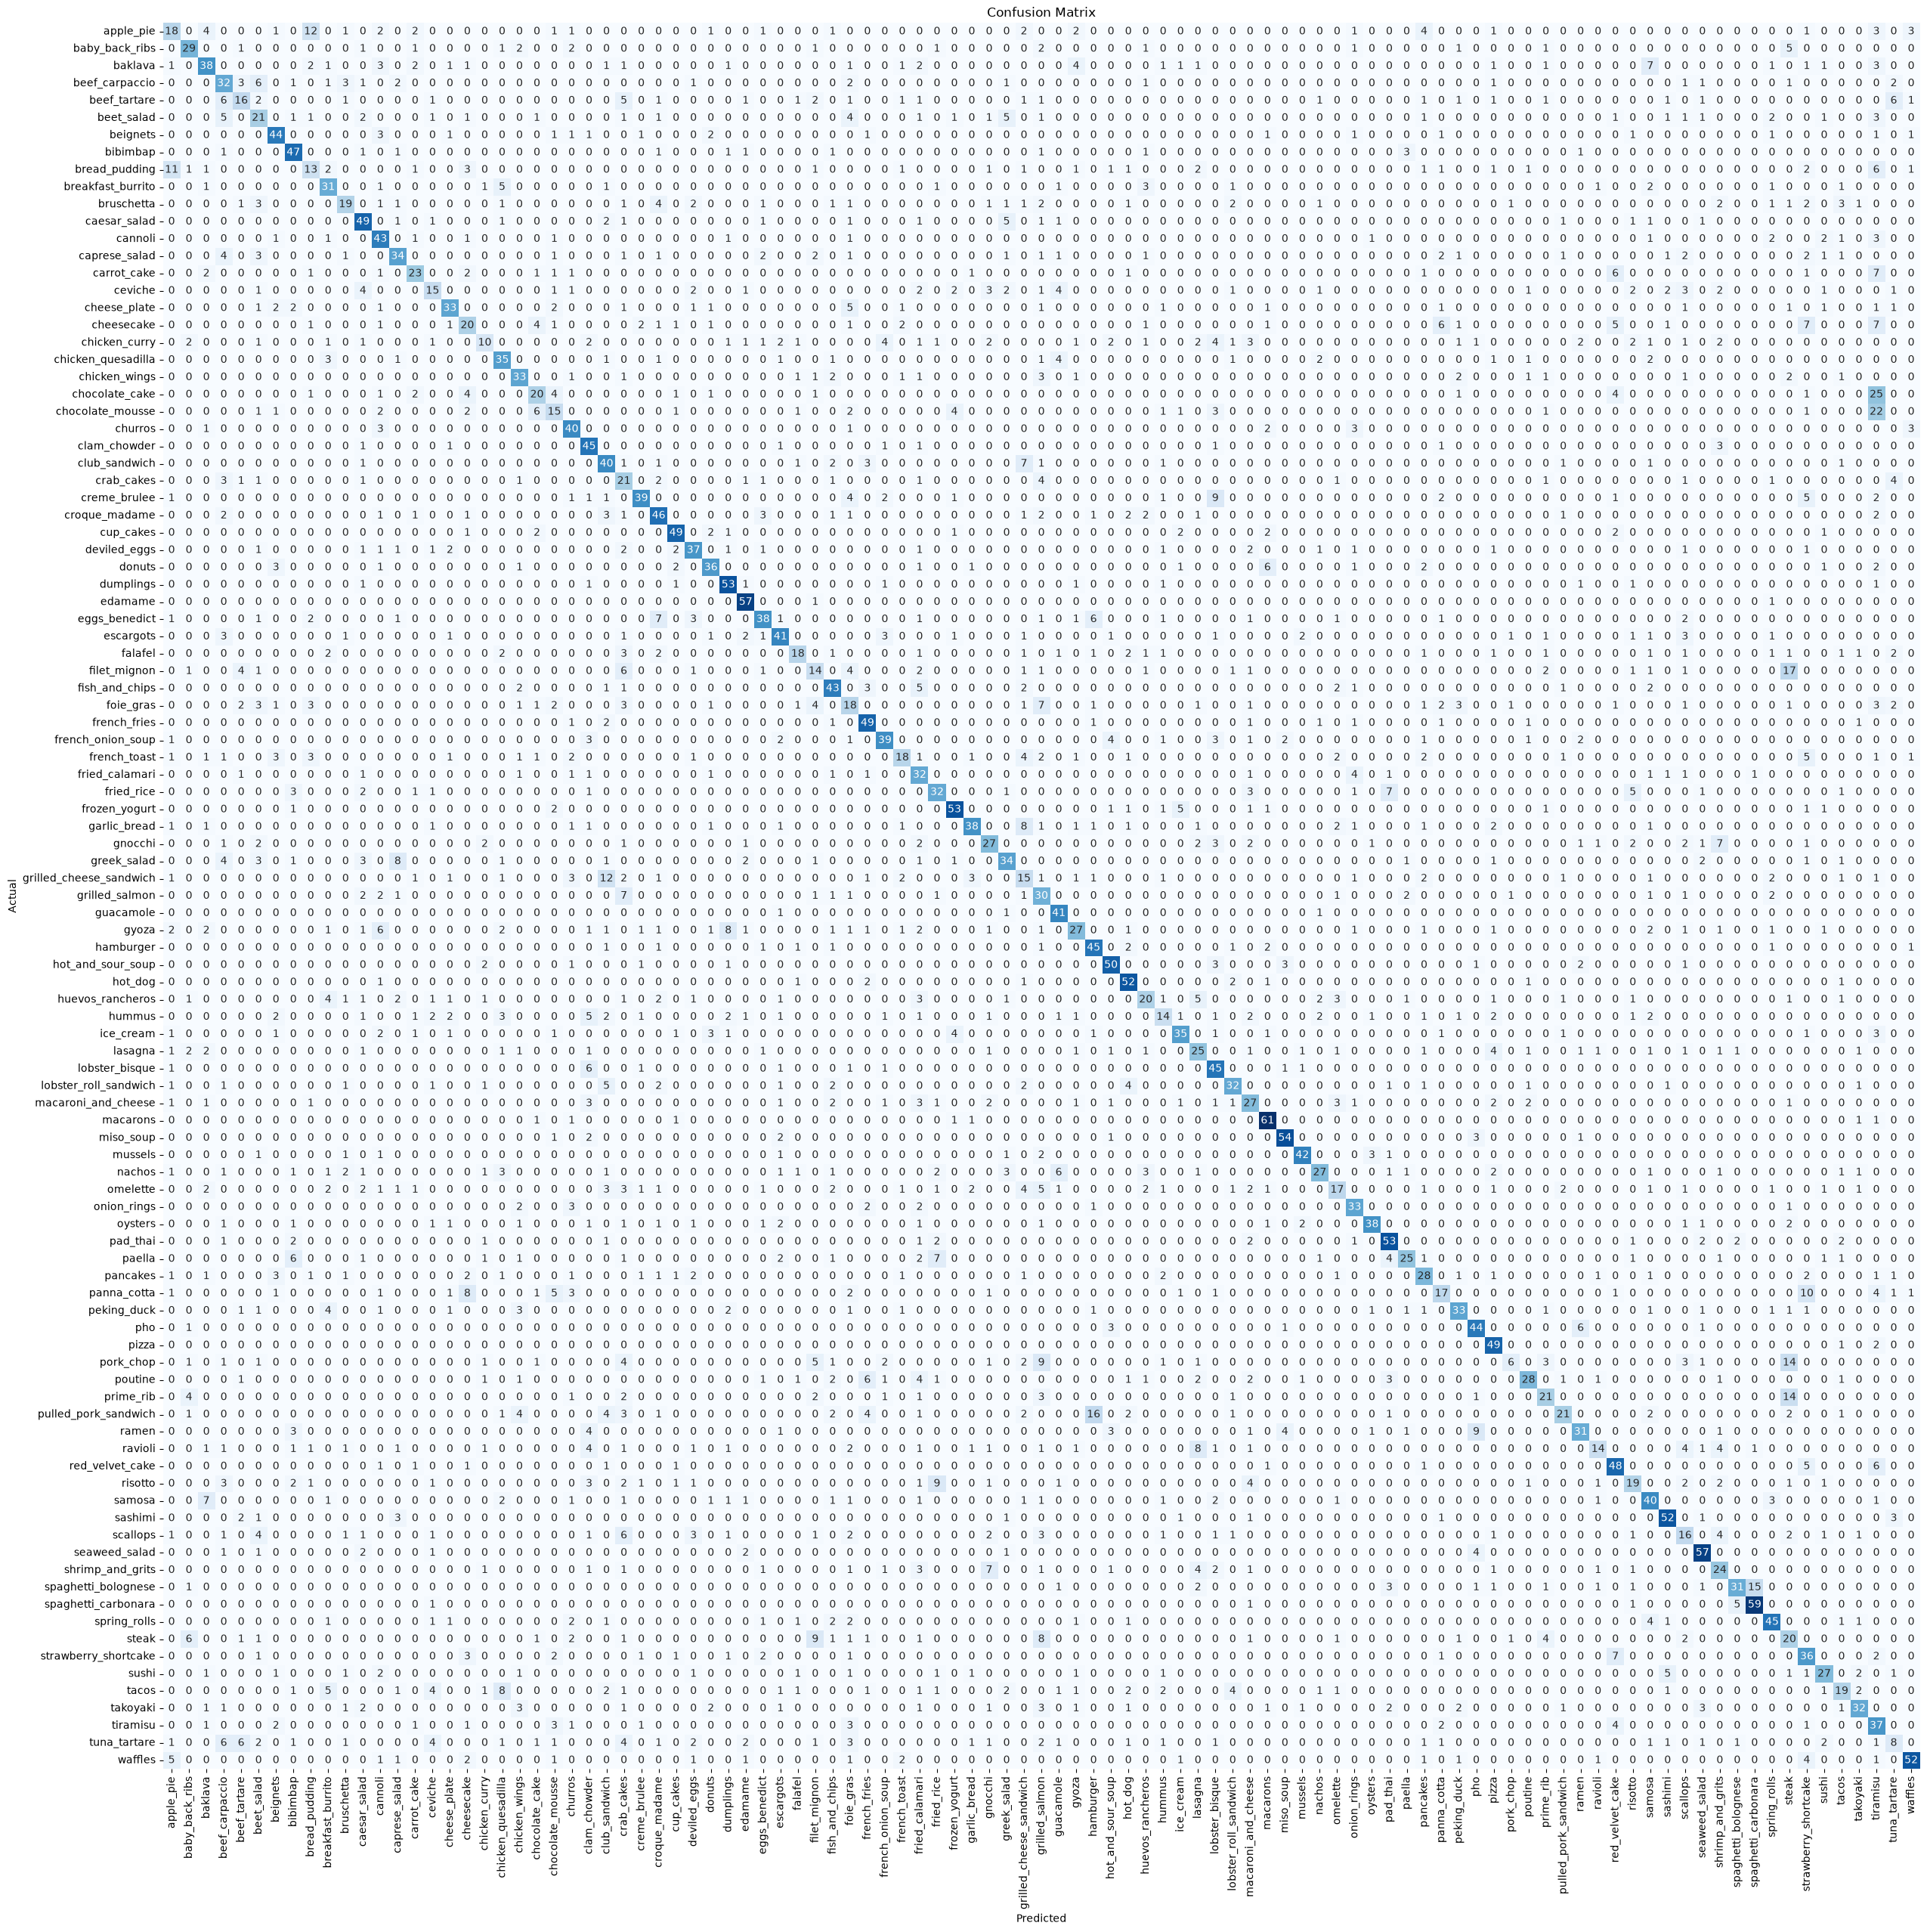

In [ ]:
plt.figure(figsize=(30,30))
sns.heatmap(cm, annot= True, fmt='g', vmin = 0, cmap='Blues', cbar= False)
plt.xticks(ticks= np.arange(101)+0.5, labels=test_images.class_indices,rotation=90)
plt.yticks(ticks= np.arange(101)+0.5, labels=test_images.class_indices,rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("classification_report:\n------------\n", clr)

classification_report:
------------
                          precision    recall  f1-score   support

              apple_pie       0.34      0.29      0.31        62
         baby_back_ribs       0.58      0.58      0.58        50
                baklava       0.56      0.49      0.52        78
         beef_carpaccio       0.40      0.53      0.46        60
           beef_tartare       0.40      0.29      0.34        55
             beet_salad       0.33      0.36      0.34        59
               beignets       0.67      0.71      0.69        62
               bibimbap       0.64      0.78      0.70        60
          bread_pudding       0.30      0.24      0.27        54
      breakfast_burrito       0.51      0.61      0.55        51
             bruschetta       0.51      0.34      0.41        56
           caesar_salad       0.58      0.71      0.64        69
                cannoli       0.51      0.72      0.60        60
          caprese_salad       0.57      0.52      0.

## Conclsusion
Based on the confusion matrix, the model performed fairly well in classifying different types of food images. The diagonal values show that the model correctly predicted many images in their actual categories. However, some mistakes occurred when certain foods had similar visual features. For example, images of chocolate cake and chocolate mousse were sometimes incorrectly predicted as tiramisu because these desserts can have similar colors, textures, and presentation styles. Overall, the model shows a good ability to recognize food categories. For future improvement, adding more images of similar-looking dishes could help the model better learn the differences between those classes and improve classification accuracy.

